# Offline Eval for Comparison to Ground Truth Values

In [61]:
import yaml
import json
import re
import numpy as np
import pandas as pd
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from skimage.morphology import skeletonize
from skimage import img_as_ubyte
import matplotlib.font_manager as fm
from scipy.stats import linregress
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from pathlib import Path
import matplotlib.patches as patches

from offline_eval_functions import *

# Import Predictions & Metadata

In [62]:
experiment = 'sharkcrop_altitude'  # define your experiment

In [63]:
os.chdir("/Volumes/JWS_2025/cv4e-bodycondition/sharkbody_seg/") 
project_root = Path.cwd()
dataset_root = project_root / 'dataset'
annot_path = project_root /  'dataset/annotations'

# config 
config_file_path = project_root / f'runs/unet_smp/{experiment}/config/config.yaml'
with open(config_file_path, 'r') as file: cfg = yaml.safe_load(file) # load yaml as cfg

# predictions
root_predictions = project_root / f'runs/unet_smp/{experiment}/checkpoints/predictions'
pred_files = [f for f in sorted(os.listdir(root_predictions)) if f.startswith("pred_")]
img_files = [f for f in sorted(os.listdir(root_predictions)) if f.startswith("img_")]

# original images
root_images = dataset_root / f'images'

# annotations 
annotations = {}
for split in ['train', 'val', 'test']:
    file_path = os.path.join(annot_path, f'{split}.json')
    with open(file_path, 'r') as f:
        annotations[split] = json.load(f)

# metadata
metadata = dataset_root / 'metadata/centerpoints/centerpoints.csv' # center point coords and EXIF data
metadata_calib = dataset_root / 'metadata/centerpoints/calibrationpoints.csv' # calibration object sizes and EXIF data
metadata_lengths = dataset_root / 'metadata/shark_lengths_pixels.csv' # pixel lengths from ImageJ
metadata_ids = dataset_root / 'metadata/shark_id.csv' # shark individual IDs

# font
arial_path = dataset_root / "metadata/plotting/arial.ttf" # font path
fm.fontManager.addfont(arial_path)
plt.rcParams['font.family'] = 'Arial'

# export folder
dir_predictions_morphometrics = project_root/ f'runs/unet_smp/{experiment}/eval/predictions_morphometrics'

In [64]:
# load EXIF/CVAT metadata
df_metadata, df_calib_metadata = pd.read_csv(metadata), pd.read_csv(metadata_calib)

# generate/apply flight-date altitude corrections
df_corrections = compute_group_calibrations(df_calib_metadata)
df_metadata_corrected = apply_altitude_calibration(df_metadata, df_corrections)

# load imageJ lengths and IDs
df_lengths, df_ids = pd.read_csv(metadata_lengths), pd.read_csv(metadata_ids)

# merge shark EXIF, imageJ, and ID metadata 
df_meta = df_metadata_corrected.merge(df_lengths, on='filename', how='left') 
df_meta = df_meta.merge(df_ids, on='filename', how='left')

# build skeleton df
df_skel = process_biometrics(root_predictions, pred_files, use_clean=True, use_extend=True)

# merge skeleton with shark metadata
merged_df= pd.merge(df_meta, df_skel, on='filename', how='left')

# crop-based pixel reconstruction
crop_size, img_size = cfg['crop_size'], cfg['image_size'] # define default crop size, final img size
use_custom_crop = cfg['use_custom_crop'] # custom crop

KeyboardInterrupt: 

In [ ]:
# merge skeleton with shark metadata
merged_df= pd.merge(df_meta, df_skel, on='filename', how='left')

# crop-based pixel reconstruction
crop_size, img_size = cfg['crop_size'], cfg['image_size'] # define default crop size, final img size
use_custom_crop = cfg['use_custom_crop'] # custom crop

# photogrammetric conversions
merged_df = reconstruct_pixels_from_crop(merged_df, crop_size, img_size, use_custom_crop)
merged_df = photogrammetric_conversion(merged_df) 

In [67]:
# additional functionality - compute visual lengths
ft_to_cm = 30.48
merged_df['VisualLength_cm'] = merged_df['White.Shark.ID'].apply(
    lambda x: pd.to_numeric(x.split('_')[-1], errors='coerce') * ft_to_cm
    if isinstance(x, str) and x.count('_') >= 2 else None)
merged_df['sex'] = merged_df['White.Shark.ID'].apply(
    lambda x: (x.split('_')[-2]) if isinstance(x, str) and x.count('_') >= 2 else None)

# replace na splits with 'deploy'
merged_df['split'] = merged_df['split'].fillna('deploy')

# Export final csv

In [68]:
export_path = project_root / f'runs/unet_smp/{experiment}/eval/evaluation.csv'
merged_df.to_csv(export_path)

In [ ]:
# export csv or read in current csv
export_path = project_root / f'runs/unet_smp/{experiment}/eval/evaluation.csv'
#merged_df.to_csv(export_path)
merged_df = pd.read_csv(export_path)

# Visualization 

In [7]:
# build masks list
masks = []
for file in pred_files:
    mask_path = os.path.join(root_predictions, file)
    mask = Image.open(mask_path)
    mask = np.array(mask)
    mask = connect_clean_mask(mask)
    masks.append(mask)  

# build image list
imgs = []
for file in img_files:
    img_path = os.path.join(root_predictions, file)
    img = Image.open(img_path)
    img = np.array(img)
    imgs.append(img)

In [8]:
def plot_schematic(mask, ax=None):
    """
    Plot the cleaned mask with the full skeleton line and LS, FS, PS cross-sections overlaid.
    """
    mask_cleaned = connect_clean_mask(mask)
    mask_skeleton = create_skeleton(mask_cleaned)
    skeleton_extended = compute_extended_path(mask_skeleton, mask_cleaned,num_points_src=5, num_points_dst=5)[3]
    skeleton_resampled = resample_line(skeleton_extended)

    # cross-sections 
    cross_sectional_points = get_cross_sectional_points(skeleton_resampled, mask_cleaned)
    ls_fs_ps = get_ls_fs_ps(cross_sectional_points, mask)

    # color scheme
    span_colors = { "LS": "#66F2E8", "FS": "#68C130", "PS": "#CED118"}
    skeleton_color = "#FF5100" 

    # set up axis
    if ax is None: fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_facecolor("black")
    ax.imshow(mask, cmap="gray", vmin=0, vmax=255, alpha=1)

    # plot skeleton
    if len(skeleton_resampled) > 1:
        xs = [x for y, x in skeleton_resampled]
        ys = [y for y, x in skeleton_resampled]
        ax.plot(xs, ys, color=skeleton_color, linewidth=1.5, label="Total Length (TL)")
        ax.scatter(xs, ys, color=skeleton_color, s=5, zorder=2, label="_nolegend_")

    # draw span helper
    def draw_span(points, label_key, label):
        if points:
            forward, backward = points
            color = span_colors[label_key]
            ax.plot([forward[1], backward[1]], [forward[0], backward[0]],color=color, linewidth=1.5, label=label)
            ax.scatter([forward[1], backward[1]], [forward[0], backward[0]],color=color, s=10, zorder=3)

    # LS (25%), FS (40%), PS (50%)
    draw_span(ls_fs_ps.get("LS", {}).get("points", None), "LS", "Lateral Span (LS)")
    draw_span(ls_fs_ps.get("FS", {}).get("points", None), "FS", "Frontal Span (FS)")
    draw_span(ls_fs_ps.get("PS", {}).get("points", None), "PS", "Proximal Span (PS)")

    ax.axis("off")
    ax.legend(loc="lower left", fontsize=6)
    
    return ax


Figure saved as:
PNG: /Volumes/JWS_2025/cv4e-bodycondition/sharkbody_seg/docs/figures/Figure1.png
TIFF: /Volumes/JWS_2025/cv4e-bodycondition/sharkbody_seg/docs/figures/Figure2.tiff


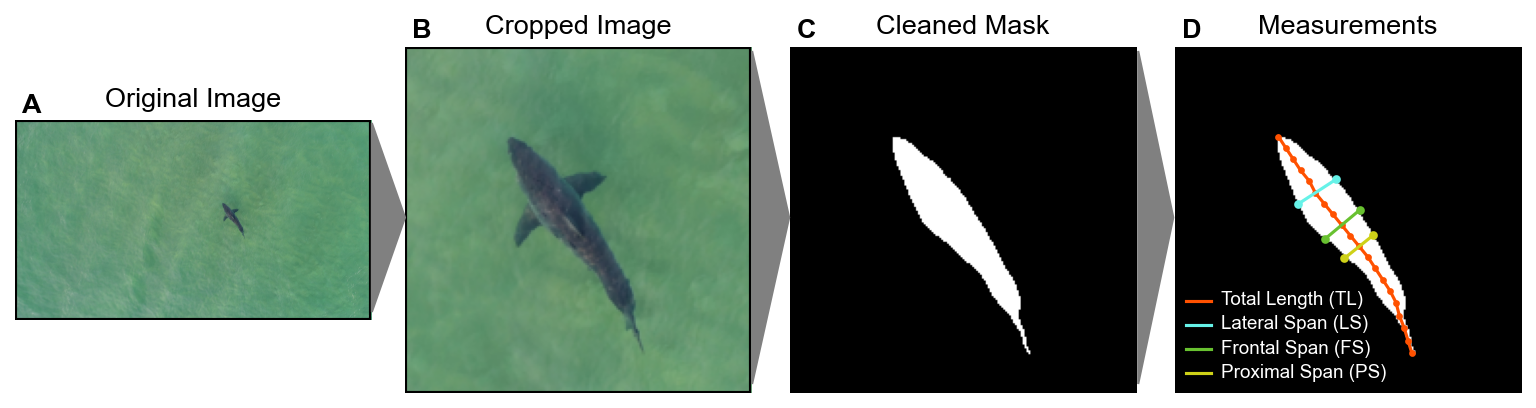

In [37]:
# example schematic
i = 1576
filename = "11012023PAMB1305.JPG"

# get images
img_path = os.path.join(root_images, filename)
orig = np.array(Image.open(img_path))

crop = imgs[i]
pred_mask = np.array(Image.open(os.path.join(root_predictions, pred_files[i])))  # raw pred before cleaning
clean_mask = masks[i]

# custom zoom 
def zoom_center(img, zoom_factor=1.5):
    """Zooms into the center of the image by the given zoom_factor."""
    h, w = img.shape[:2]
    new_h, new_w = int(h / zoom_factor), int(w / zoom_factor)
    top = (h - new_h) // 2
    left = (w - new_w) // 2
    return img[top:top+new_h, left:left+new_w]

# create schematic plot
fig, axes = plt.subplots(1, 4, figsize=(13, 3), dpi=150)

titles = ["Original Image", "Cropped Image", "Cleaned Mask", "Measurements"]
letters = ["A", "B", "C", "D"]
images = [orig, crop, clean_mask, None]

for idx, ax in enumerate(axes):
    if idx == 0:
        # Panel A: Original (no zoom)
        ax.imshow(images[idx])
    elif idx in [1, 2]:
        # Panels B and C: zoomed
        img_zoomed = zoom_center(images[idx], zoom_factor=1.25)
        ax.imshow(img_zoomed, cmap="gray" if idx == 2 else None)
    elif idx == 3:
        # Panel D: zoomed version for schematic
        zoomed_mask = zoom_center(clean_mask, zoom_factor=1.25)
        plot_schematic(zoomed_mask, ax=ax)

    ax.set_title(titles[idx], fontsize=13)
    ax.axis("off")

    # black outline around each panel
    rect = patches.Rectangle(
        (0, 0), 1, 1, transform=ax.transAxes,
        linewidth=2, edgecolor="black", facecolor="none", zorder=10)
    ax.add_patch(rect)

    # add letter just above each panel (moved slightly down from before)
    ax.text(0.02, 1.01, letters[idx],
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="bottom", ha="left",
        color="black", zorder=11)

# --- gray triangles between panels ---
y_center = 0.5  # shared vertical alignment
triangles = [
    [(0.325, y_center), (0.308, y_center + 0.21), (0.308, y_center - 0.21)],  # between A-B
    [(0.522, y_center), (0.503, y_center + 0.37), (0.503, y_center - 0.37)],  # between B-C
    [(0.719, y_center), (0.701, y_center + 0.37), (0.701, y_center - 0.37)]]

for tri in triangles:
    polygon = Polygon(tri, closed=True, color="gray", transform=fig.transFigure, clip_on=False)
    fig.patches.append(polygon)

leg = axes[3].get_legend()
if leg is not None:
    for text in leg.get_texts():
        text.set_fontsize(9) 
        text.set_color("white") # white text
    leg.set_bbox_to_anchor((0, 0.0))
    leg.get_frame().set_visible(False)  # no legend box
plt.subplots_adjust(wspace=0.08)

# export figure
figure_dir = project_root / 'docs' / 'figures'
png_path = figure_dir / "Figure1.png"
tiff_path = figure_dir / "Figure2.tiff"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(tiff_path, dpi=300, bbox_inches="tight")

print(f"Figure saved as:\nPNG: {png_path}\nTIFF: {tiff_path}")

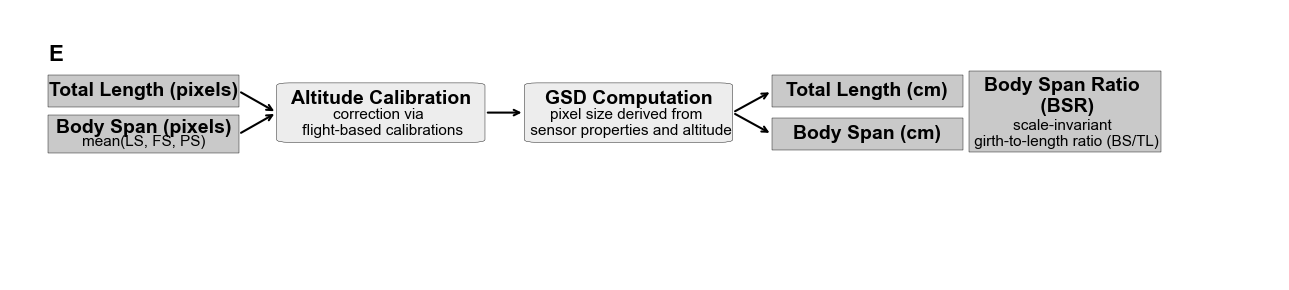

In [320]:
fig, ax = plt.subplots(figsize=(13, 3))  # slightly shorter figure
ax.axis("off")

# Box size
box_w, box_h = 0.20, 0.20

# Y positions (reduced spacing)
y_top = 0.6
y_middle = 0.44

# X positions (bring rightmost boxes closer)
x_left = 0.04
x_center = 0.22
x_right1 = 0.415
x_right2 = 0.61

# Function to add box with main text and optional subtitle
def add_box(x, y, main_text, subtitle=None, facecolor="#C9C9C9",boxstyle="round,pad=0.01"):
    # Adjust box height based on subtitle
    if "\n" in main_text:
        this_box_h = box_h*1.4
        this_box_w = box_w*0.655
        main_y = y + this_box_h*0.7  # slightly higher for main text
        subtitle_y = y + this_box_h*0.2
    elif subtitle and "\n" in subtitle:
        this_box_h = box_h  # default height for multi-line subtitle
        this_box_w = box_w*0.72
        main_y = y + this_box_h*0.75  # slightly higher for main text
        subtitle_y = y + this_box_h*0.3
    elif subtitle:
        this_box_h = box_h * 0.6  # slightly shorter if single-line subtitle
        this_box_w = box_w*0.65 # slightly shorter width
        main_y = y + this_box_h*0.7
        subtitle_y = y + this_box_h*0.25
    else:
        this_box_h = box_h * 0.5  # shortest if no subtitle
        this_box_w = box_w*0.65
        main_y = y + this_box_h*0.5  # center main text vertically
        subtitle_y = None

    box = patches.FancyBboxPatch(
        (x, y), this_box_w, this_box_h,
        boxstyle=boxstyle,
        linewidth=0.3,
        facecolor=facecolor)
    ax.add_patch(box)
    
    # Add main text
    ax.text(x + this_box_w/2, main_y, main_text,
            ha="center", va="center", fontsize=14, fontweight="bold")

    # Add subtitle if present
    if subtitle and subtitle_y is not None:
        ax.text(x + this_box_w/2, subtitle_y, subtitle,
                ha="center", va="center", fontsize=11)

    return box

# --- Create boxes ---
tl_box = add_box(x_left, y_top + 0.05, "Total Length (pixels)",
                 boxstyle="square,pad=0.01")
bs_box = add_box(x_left, y_middle + 0.04, "Body Span (pixels)", subtitle="mean(LS, FS, PS)",
                 boxstyle="square,pad=0.01")

alt_box = add_box(x_center, (y_top + y_middle)/2, "Altitude Calibration",
                  subtitle="correction via \n flight-based calibrations", facecolor="#EDEDED")

gsd_box = add_box(x_right1, (y_top + y_middle)/2, "GSD Computation",
                  subtitle="pixel size derived from \n sensor properties and altitude", facecolor='#EDEDED')

tl_cm_box = add_box(x_right2, y_top + 0.05, "Total Length (cm)",
                    boxstyle="square,pad=0.01")
bs_cm_box = add_box(x_right2, y_middle + 0.05, "Body Span (cm)",
                    boxstyle="square,pad=0.01")

bsr_box = add_box(x_right2 + 0.155, (y_top + y_middle)/2 -0.035, "Body Span Ratio \n (BSR)",
                  subtitle="scale-invariant \n girth-to-length ratio (BS/TL)",
                  boxstyle="square,pad=0.01")

# --- Function to add arrows ---
def add_arrow(box_from, box_to):
    # Get the actual box dimensions
    x_start = box_from.get_x() + box_from.get_width() + 0.01
    y_start = box_from.get_y() + box_from.get_height()/2
    x_end = box_to.get_x() - 0.01
    y_end = box_to.get_y() + box_to.get_height()/2
    ax.annotate("",
                xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

# --- Add arrows ---
add_arrow(tl_box, alt_box)
add_arrow(bs_box, alt_box)
add_arrow(alt_box, gsd_box)
add_arrow(gsd_box, tl_cm_box)
add_arrow(gsd_box, bs_cm_box)

# add panel marking
ax.text(0.03, 0.87, "E", transform=ax.transAxes,
        fontsize=16, fontweight="bold", va="top", ha="left", color="black")

plt.tight_layout()
plt.show()


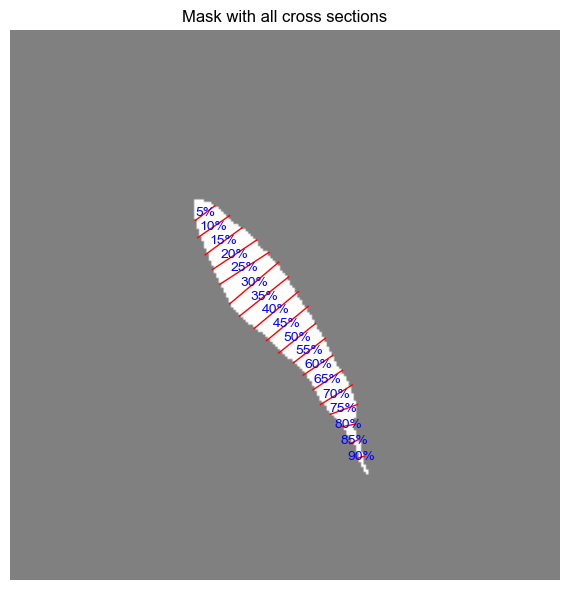

In [194]:
plot_mask_with_all_cross_sections(pred_mask)

## Export Predictions_Morphometrics 

In [1]:
# export skeleton and cross section predictions 
for i in range(len(masks)): 
    mask = masks[i] # get mask
    img = imgs[i] # get image
    base_name = img_files[i].split('_')[1].split('.')[0]  # get base name
    img_name = f'morphometrics_{base_name}.png' # create image name
    save_path = os.path.join(dir_predictions_morphometrics, img_name) # create save path
    fig = plot_mask_with_skeleton_and_cross_sections(img, mask) # store plot
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0.1, transparent=True)
    plt.close(fig)

NameError: name 'masks' is not defined

In [ ]:
# export plots with line extension
for i in range(len(masks)): 
    mask = masks[i] # get mask
    img = imgs[i] # get image
    base_name = img_files[i].split('_')[1].split('.')[0]  # get base name
    img_name = f'lineextension_{base_name}.png' # create image name
    save_path = os.path.join(dir_predictions_morphometrics, img_name) # create save path
    
    skeleton = create_skeleton(mask)
    src_coords, dst_coords, shortest_path, extended_path = compute_extended_path(skeleton, mask)
    fig = plot_extended_path(extended_path, shortest_path, src_coords, dst_coords, img) # store plot

    fig.savefig(save_path, bbox_inches='tight', pad_inches=0.1, transparent=True) # save plot
    plt.close(fig)

# Ablations

In [8]:
cleaned_df = pd.read_csv(f'/home/Alexandra/Projects/bodycondition/sharkbody_seg/runs/unet_smp/{experiment}/eval/evaluation.csv')
no_clean_df = pd.read_csv(f'/home/Alexandra/Projects/bodycondition/sharkbody_seg/runs/unet_smp/{experiment}/eval/ablation_clean_evaluation.csv')
no_extend_df = pd.read_csv(f'/home/Alexandra/Projects/bodycondition/sharkbody_seg/runs/unet_smp/{experiment}/eval/ablation_extend_evaluation.csv')

In [18]:
# only looking at ablation performance on val and test
splits = ['val', 'test']

conditions = {'Cleaned': cleaned_df, 'No Clean': no_clean_df, 'No Extend': no_extend_df}

# define function to compute R² for a given df and split
def compute_r2(df, split):
    df_split = df[df['split'] == split].dropna(subset=['TL_pixels', 'TL_skel_pixels'])
    if df_split.empty:
        return None
    slope, intercept, r_value, _, _ = linregress(df_split['TL_pixels'], df_split['TL_skel_pixels'])
    return r_value ** 2, len(df_split)

results = []
for split in splits:
    for cond_name, df_cond in conditions.items():
        df_split = df_cond[df_cond['split'] == split].dropna(subset=['TL_pixels', 'TL_skel_pixels'])
        if df_split.empty:
            continue
        residuals = df_split['TL_skel_pixels'] - df_split['TL_pixels']
        mae = np.mean(np.abs(residuals))
        rmse = np.sqrt(np.mean(residuals**2))
        slope, intercept, r_value, _, _ = linregress(df_split['TL_pixels'], df_split['TL_skel_pixels'])
        r_squared = r_value**2
        results.append({'split': split.capitalize(),'condition': cond_name,'R²': r_squared,
            'MAE_px': mae,'RMSE_px': rmse,'n': len(df_split)})

residuals_df = pd.DataFrame(results)
print(residuals_df)


  split  condition        R²     MAE_px    RMSE_px    n
0   Val    Cleaned  0.996145   6.481675   9.635760  171
1   Val   No Clean  0.993606   7.692943  12.542010  171
2   Val  No Extend  0.984034  24.392862  31.983411  171
3  Test    Cleaned  0.976091  16.876552  43.289280  183
4  Test   No Clean  0.972963  18.145731  46.209972  183
5  Test  No Extend  0.955103  45.458179  74.554435  183


In [19]:
# Define comparisons
comparisons = [
    ('No Extend', 'Cleaned', 'Skeleton Extension'),
    ('No Clean', 'Cleaned', 'Mask Cleaning')
]

delta_r2_list = []

for split in ['Val', 'Test']:
    df_split = residuals_df[residuals_df['split'] == split].set_index('condition')
    
    for from_cond, to_cond, label in comparisons:
        delta_r2 = df_split.loc[to_cond, 'R²'] - df_split.loc[from_cond, 'R²']
        delta_r2_list.append({
            'split': split,
            'comparison': label,
            'delta_R²': delta_r2
        })

delta_r2_df = pd.DataFrame(delta_r2_list)
print(delta_r2_df)


  split          comparison  delta_R²
0   Val  Skeleton Extension  0.012111
1   Val       Mask Cleaning  0.002539
2  Test  Skeleton Extension  0.020988
3  Test       Mask Cleaning  0.003127


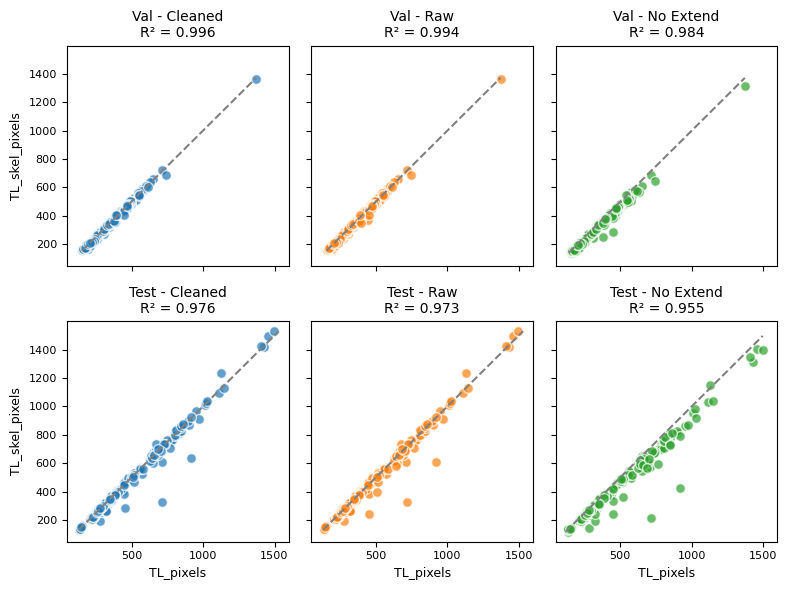

In [ ]:
# Define colors for each condition
condition_colors = {'Cleaned': '#1f77b4', 'No Clean': '#ff7f0e', 'No Extend': '#2ca02c'}

fig, axes = plt.subplots(len(splits), len(conditions), figsize=(8, 6), sharex=True, sharey=True)

for i, split in enumerate(splits):
    for j, (cond_name, df_cond) in enumerate(conditions.items()):
        ax = axes[i, j] if len(splits) > 1 else axes[j]
        df_split = df_cond[df_cond['split'] == split].dropna(subset=['TL_pixels', 'TL_skel_pixels'])
        if df_split.empty:
            continue
        
        # Scatter plot
        ax.scatter(df_split['TL_pixels'], df_split['TL_skel_pixels'],
                   color=condition_colors[cond_name], s=50, alpha=0.7, edgecolor='white')

        min_val = min(df_split['TL_pixels'].min(), df_split['TL_skel_pixels'].min())
        max_val = max(df_split['TL_pixels'].max(), df_split['TL_skel_pixels'].max())
        ax.plot([min_val, max_val], [min_val, max_val], '--', color='gray')

        # R²
        slope, intercept, r_value, _, _ = linregress(df_split['TL_pixels'], df_split['TL_skel_pixels'])
        r_squared = r_value**2

        ax.set_title(f'{split.capitalize()} - {cond_name}\nR² = {r_squared:.3f}', fontsize=10)
        if j == 0:
            ax.set_ylabel('TL_skel_pixels', fontsize=9)
        if i == len(splits)-1:
            ax.set_xlabel('TL_pixels', fontsize=9)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


# Plotting Pixels

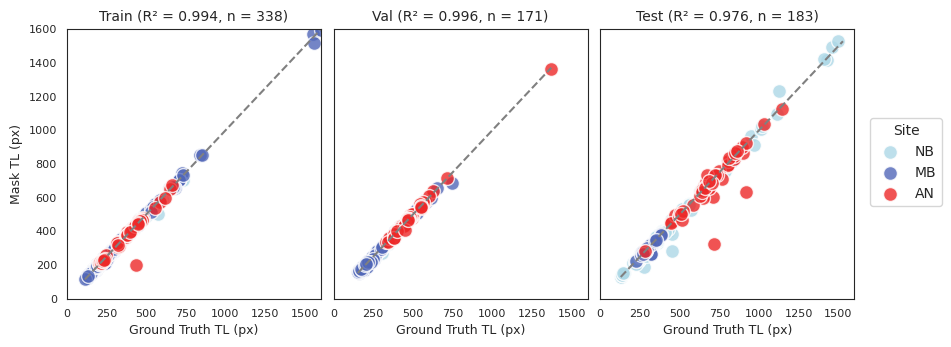

In [33]:
# r2 computation - split-specific; colored by site

# extract site
merged_df['site'] = merged_df['filename'].str[10:12]

# define colors
site_color_map = {'NB': '#ADD8E6', 'MB': '#5167b8', 'AN': '#ed2828'}
unique_sites = sorted(merged_df['site'].dropna().unique())
site_to_color = {site: site_color_map.get(site, '#333333') for site in unique_sites}
merged_df['site_color'] = merged_df['site'].map(site_to_color)

# Create side-by-side subplots for train, val, and test
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5), sharex=True, sharey=True)
splits = ['train', 'val', 'test']

for ax, split in zip(axes, splits):
    df_split = merged_df[merged_df['split'] == split].dropna(subset=['TL_pixels', 'TL_skel_pixels', 'site_color'])

    if not df_split.empty:
        # R² computation
        slope, intercept, r_value, _, _ = linregress(df_split['TL_pixels'], df_split['TL_skel_pixels'])
        r_squared = r_value ** 2

        # Scatter plot, grouped and colored by site
        for site in df_split['site'].unique():
            subset = df_split[df_split['site'] == site]
            ax.scatter(
                subset['TL_pixels'], subset['TL_skel_pixels'],
                label=site, color=site_color_map.get(site, '#333333'),
                s=100, edgecolor='white', alpha=0.8
            )

        # Plot the 1:1 line
        min_val = min(df_split['TL_pixels'].min(), df_split['TL_skel_pixels'].min())
        max_val = max(df_split['TL_pixels'].max(), df_split['TL_skel_pixels'].max())
        ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray')

        # Titles and axis labels
        n = len(df_split)
        ax.set_title(f'{split.capitalize()} (R² = {r_squared:.3f}, n = {n})', fontsize=10)

        ax.set_xlabel('Ground Truth TL (px)', fontsize=9)
        if split == 'train':
            ax.set_ylabel('Mask TL (px)', fontsize=9)
        ax.tick_params(labelsize=8)

# Set limits
plt.xlim(0, 1600)
plt.ylim(0, 1600)

# Add a legend outside the plot
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # Remove duplicate labels
fig.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.01, 0.5), title='Site')

# Adjust layout
fig.subplots_adjust(wspace=0.05, right=1)
plt.show()


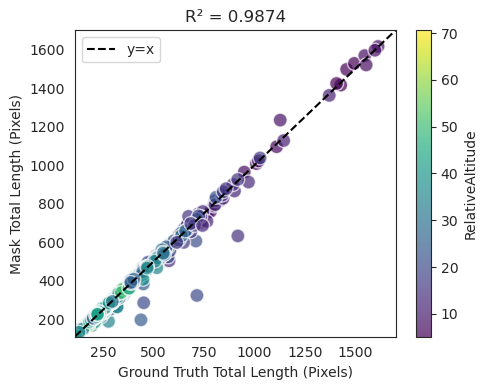

In [34]:
# r2 computation - all splits; colored by altitude
merged_df_clean = merged_df.dropna(subset=['TL_pixels', 'TL_skel_pixels'])
slope, intercept, r_value, p_value, std_err = linregress(merged_df_clean['TL_pixels'], merged_df_clean['TL_skel_pixels'])
r_squared = r_value ** 2

plt.figure(figsize=(5, 4))

# Plot the scatter points, color by 'RelativeAltitude'
scatter = plt.scatter(merged_df['TL_pixels'], merged_df['TL_skel_pixels'],
                      c=merged_df['relative_altitude'], cmap='viridis', s=100, edgecolor='w', alpha=0.7)

# Plot the y=x line (where x = y)
min_val = min(merged_df['TL_pixels'].min(), merged_df['TL_skel_pixels'].min())
max_val = max(merged_df['TL_pixels'].max(), merged_df['TL_skel_pixels'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='k', linestyle='--', label='y=x')

# labels
plt.colorbar(scatter, label='RelativeAltitude')
plt.legend(loc='upper left')
plt.xlabel('Ground Truth Total Length (Pixels)')
plt.ylabel('Mask Total Length (Pixels)')
plt.title(f'R² = {r_squared:.4f}')

plt.tight_layout()
plt.xlim(110,1700)
plt.ylim(110,1700)
plt.show()


# Photogrammetric Measurements Comparison

In [35]:
#set altitude threshold 
altitude_threshold = 10

#filter for gimbal and altitude threshold
original_df = merged_df.copy()
photog_df = original_df[original_df['corrected_relative_altitude'] > altitude_threshold]
photog_df = original_df[original_df['gimbal_pitch_deg'] < -80]

/tmp/ipykernel_1541191/1784717645.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  photog_df['site_color'] = photog_df['site'].map(site_to_color)


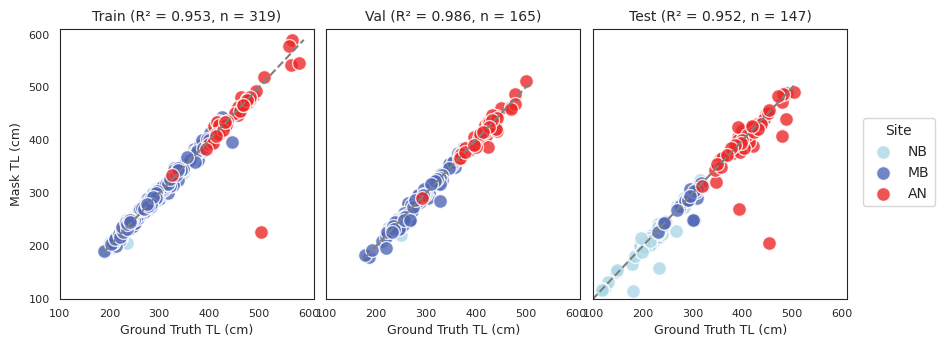

In [36]:
# r2 computation - split-specific; colored by site

# define colors
site_color_map = {'NB': '#ADD8E6', 'MB': '#5167b8', 'AN': '#ed2828'}
unique_sites = sorted(photog_df['site'].dropna().unique())
site_to_color = {site: site_color_map.get(site, '#333333') for site in unique_sites}
photog_df['site_color'] = photog_df['site'].map(site_to_color)
sns.set_style("white")

# Create side-by-side subplots for train, val, and test
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5), sharex=True, sharey=True)
splits = ['train', 'val', 'test']

for ax, split in zip(axes, splits):
    df_split = photog_df[photog_df['split'] == split].dropna(subset=['TL_cm', 'TL_skel_cm', 'site_color'])

    if not df_split.empty:
        # R² computation
        slope, intercept, r_value, _, _ = linregress(df_split['TL_cm'], df_split['TL_skel_cm'])
        r_squared = r_value ** 2

        # Scatter plot, grouped and colored by site
        for site in df_split['site'].unique():
            subset = df_split[df_split['site'] == site]
            ax.scatter(
                subset['TL_cm'], subset['TL_skel_cm'],
                label=site, color=site_color_map.get(site, '#333333'),
                s=100, edgecolor='white', alpha=0.8)

        # Plot the 1:1 line
        min_val = min(df_split['TL_cm'].min(), df_split['TL_skel_cm'].min())
        max_val = max(df_split['TL_cm'].max(), df_split['TL_skel_cm'].max())
        ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray')

        # Titles and axis labels
        n = len(df_split)
        ax.set_title(f'{split.capitalize()} (R² = {r_squared:.3f}, n = {n})', fontsize=10)

        ax.set_xlabel('Ground Truth TL (cm)', fontsize=9)
        if split == 'train':
            ax.set_ylabel('Mask TL (cm)', fontsize=9)
        ax.tick_params(labelsize=8)

# Set limits
plt.xlim(100, 610)
plt.ylim(100, 610)

# Add a legend outside the plot
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # Remove duplicate labels
fig.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.01, 0.5), title='Site')

# Adjust layout
fig.subplots_adjust(wspace=0.05, right=1)
plt.show()

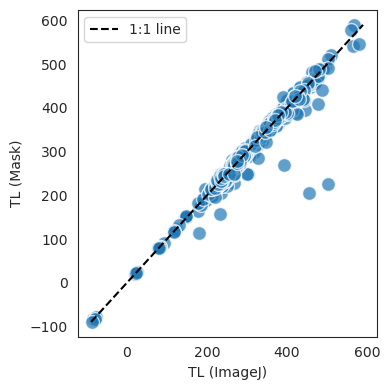

In [37]:
plt.figure(figsize=(4, 4))

scatter = plt.scatter(photog_df['TL_cm'], photog_df['TL_skel_cm'],
                      s=100, edgecolor='w', alpha=0.7)

min_val = min(photog_df['TL_skel_cm'].min(), photog_df['TL_cm'].min())
max_val = max(photog_df['TL_skel_cm'].max(), photog_df['TL_cm'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='k', linestyle='--', label='1:1 line')

plt.xlabel('TL (ImageJ)')
plt.ylabel('TL (Mask)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


# Body Condition Comparisons

In [38]:
# make cleaned df without nas
merged_df_clean = merged_df.dropna(subset=['BS_skel_pixels', 'BS_skel_cm']).copy()
merged_df_clean['BS_pixels'] = pd.to_numeric(merged_df_clean['BS_pixels'], errors='coerce')

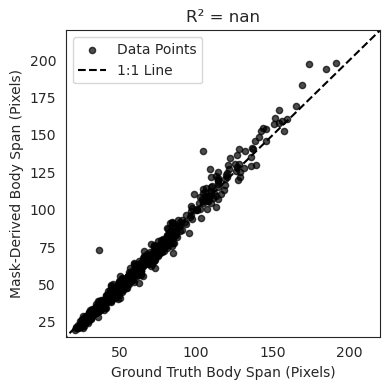

In [39]:
# r2 computation
slope, intercept, r_value, p_value, std_err = linregress(merged_df_clean['BS_skel_pixels'], merged_df_clean['BS_pixels'])
r_squared = r_value ** 2

fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(merged_df['BS_skel_pixels'], merged_df['BS_pixels'], color='black', label='Data Points', s = 20, alpha = 0.7)

# Add the 1:1 line (y = x)
min_val = min(merged_df['BS_skel_pixels'].min(), merged_df['BS_pixels'].min())
max_val = max(merged_df['BS_skel_pixels'].max(), merged_df['BS_pixels'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')  # 1:1 line in black dashed

# Title and labels
ax.set_xlabel('Ground Truth Body Span (Pixels)')
ax.set_ylabel('Mask-Derived Body Span (Pixels)')

# Add the R² value to the title
plt.title(f'R² = {r_squared:.4f}')

# Add a legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.xlim(15, 220)
plt.ylim(15, 220)
plt.show()


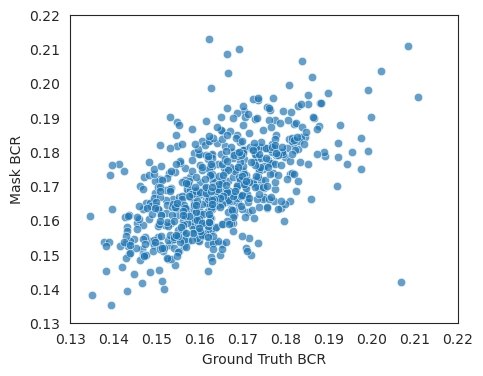

In [40]:
# Set up the plot
plt.figure(figsize=(5, 4))

# Scatter plot for BCR vs. BAI
sns.scatterplot(data=merged_df_clean, x='BSR', y='BSR_skel', alpha=0.7)
plt.xlabel('Ground Truth BCR')
plt.ylabel('Mask BCR')

plt.xlim(0.13,0.22)
plt.ylim(0.13,0.22)

# Show the plot
plt.show()

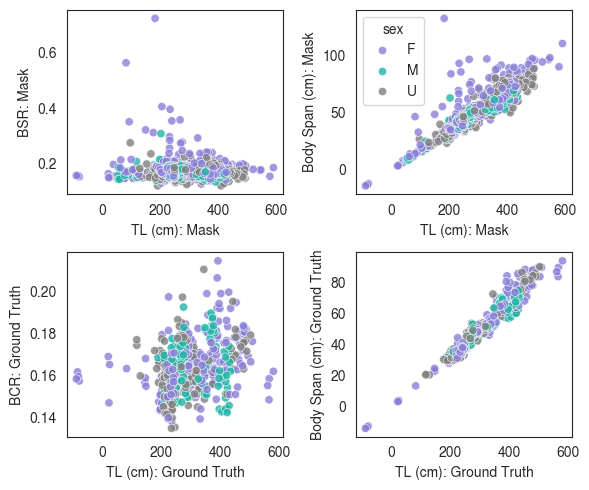

In [43]:
custom_palette = {'M': '#1fb4a7','F': '#8a7fd8','U': '#808080'}
fig, axs = plt.subplots(2, 2, figsize=(6, 5))

# First plot: TL_skel_cm vs. BSR
sns.scatterplot(data=photog_df, x='TL_skel_cm', y='BSR_skel', alpha=0.8, ax=axs[0, 0], hue='sex', palette=custom_palette, legend = False)
plt.rcParams["font.family"] = "Nimbus Sans"
axs[0, 0].set_xlabel('TL (cm): Mask')
axs[0, 0].set_ylabel('BSR: Mask')

# Second plot: TL_skel_cm vs. BS_skel_cm
sns.scatterplot(data=photog_df, x='TL_skel_cm', y='BS_skel_cm', alpha=0.8, ax=axs[0, 1], hue='sex', palette=custom_palette, legend = True)
plt.rcParams["font.family"] = "Nimbus Sans"
axs[0, 1].set_xlabel('TL (cm): Mask')
axs[0, 1].set_ylabel('Body Span (cm): Mask')

# Third plot: Calibrated_Length_cm vs. BCR
sns.scatterplot(data=photog_df, x='TL_cm', y='BSR', alpha=0.8, ax=axs[1, 0], hue='sex', palette=custom_palette, legend = False)
plt.rcParams["font.family"] = "Nimbus Sans"
axs[1, 0].set_xlabel('TL (cm): Ground Truth')
axs[1, 0].set_ylabel('BCR: Ground Truth')

# Fourth plot: Calibrated_Length_cm vs. Calibrated_LS_cm
sns.scatterplot(data=photog_df, x='TL_cm', y='BS_cm', alpha=0.8, ax=axs[1, 1], hue='sex', palette=custom_palette, legend = False)
plt.rcParams["font.family"] = "Nimbus Sans"
axs[1, 1].set_xlabel('TL (cm): Ground Truth')
axs[1, 1].set_ylabel('Body Span (cm): Ground Truth')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()